In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import curve_fit
from scipy.special import gamma
from scipy.stats import weibull_min

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')


In [2]:
# Load the final training dataset
train_final = pd.read_csv('/home/jupyter/train_final.csv')

print(f"Dataset shape: {train_final.shape}")
print(f"\nCutter breakdown:")
print(train_final['cutter'].value_counts())
print(f"\nWear range: {train_final['max_wear'].min():.1f} to {train_final['max_wear'].max():.1f}")
print(f"\nFirst 5 rows:")
print(train_final.head())

Dataset shape: (945, 15)

Cutter breakdown:
cutter
c1    315
c4    315
c6    315
Name: count, dtype: int64

Wear range: 31.4 to 234.7

First 5 rows:
   vib_x_std  vib_x_max  force_x_p2p  force_y_mean  force_x_max  vib_y_std  \
0   0.076349      0.330        6.245      0.629463        3.744   0.076315   
1   0.085350      0.399       12.646      1.118580        8.427   0.085027   
2   0.095641      0.433       17.528      2.347886       11.534   0.093816   
3   0.099032      0.443       17.945      2.721446       11.788   0.097125   
4   0.083672      0.447       16.843      2.351169       12.555   0.081350   

   force_y_max  vib_x_kurtosis  vib_y_kurtosis  force_y_kurtosis  \
0       10.724        0.132293        0.125459          5.844452   
1       14.302        0.275172        0.235982          0.530868   
2       20.826        0.262720        0.194543          0.812980   
3       24.148        0.191981        0.143043          0.681623   
4       24.337        0.303040        0.25

In [3]:
# Define three degradation models to compare

def power_law(t, a, b):
    """wear = a * t^b"""
    return a * np.power(t, b)

def linear_model(t, a, b):
    """wear = a + b*t"""
    return a + b * t

def exponential_model(t, a, b):
    """wear = a * e^(b*t)"""
    return a * np.exp(b * t)


In [4]:
# Load wear data for all three training cutters
def load_wear(cutter_id):
    wear_df = pd.read_csv(f'/home/jupyter/milling/{cutter_id}/{cutter_id}_wear.csv',
                          header=0,
                          names=['cut', 'flute_1', 'flute_2', 'flute_3'])
    for col in ['cut', 'flute_1', 'flute_2', 'flute_3']:
        wear_df[col] = pd.to_numeric(wear_df[col], errors='coerce')
    wear_df['max_wear'] = wear_df[['flute_1', 'flute_2', 'flute_3']].max(axis=1)
    return wear_df

wear_c1 = load_wear('c1')
wear_c4 = load_wear('c4')
wear_c6 = load_wear('c6')

print("Wear data loaded")
print(f"C1: {len(wear_c1)} cuts, max wear: {wear_c1['max_wear'].max():.1f}")
print(f"C4: {len(wear_c4)} cuts, max wear: {wear_c4['max_wear'].max():.1f}")
print(f"C6: {len(wear_c6)} cuts, max wear: {wear_c6['max_wear'].max():.1f}")

Wear data loaded
C1: 315 cuts, max wear: 172.7
C4: 315 cuts, max wear: 210.9
C6: 315 cuts, max wear: 234.7


In [5]:
# Fit all three models to each cutter and compare
def fit_and_compare(wear_df, cutter_id):
    t = wear_df['cut'].values
    w = wear_df['max_wear'].values
    
    results = {}
    
    # Fit each model
    models = {
        'power_law': power_law,
        'linear': linear_model,
        'exponential': exponential_model
    }
    
    for name, model in models.items():
        try:
            # curve_fit finds the best a and b for each model
            params, _ = curve_fit(model, t, w, maxfev=10000)
            
            # Predict wear using fitted parameters
            w_pred = model(t, *params)
            
            # Calculate RMSE
            rmse = np.sqrt(np.mean((w - w_pred)**2))
            
            results[name] = {
                'params': params,
                'rmse': rmse
            }
            
            print(f"{cutter_id} - {name}: a={params[0]:.4f}, b={params[1]:.4f}, RMSE={rmse:.4f}")
        
        except Exception as e:
            print(f"{cutter_id} - {name}: Failed to fit - {e}")
    
    return results

print("=== C1 ===")
results_c1 = fit_and_compare(wear_c1, 'c1')

print("\n=== C4 ===")
results_c4 = fit_and_compare(wear_c4, 'c4')

print("\n=== C6 ===")
results_c6 = fit_and_compare(wear_c6, 'c6')

=== C1 ===
c1 - power_law: a=26.0721, b=0.3012, RMSE=12.0961
c1 - linear: a=67.2940, b=0.2950, RMSE=7.2035
c1 - exponential: a=-0.0000, b=1.0000, RMSE=62611120316290946448322358684108143497108430423780392957714927279249890881671899447890477176613223476875835296115199049728.0000

=== C4 ===
c4 - power_law: a=9.4492, b=0.4877, RMSE=20.2472
c4 - linear: a=45.8245, b=0.3834, RMSE=16.4211
c4 - exponential: a=-0.0000, b=1.0000, RMSE=62611120316290946448322358684108143497108430423780392957714927279249890881671899447890477176613223476875835296115199049728.0000

=== C6 ===
c6 - power_law: a=14.2203, b=0.4610, RMSE=22.3458
c6 - linear: a=63.3726, b=0.4835, RMSE=15.7742
c6 - exponential: a=-0.0000, b=1.0000, RMSE=62611120316290946448322358684108143497108430423780392957714927279249890881671899447890477176613223476875835296115199049728.0000


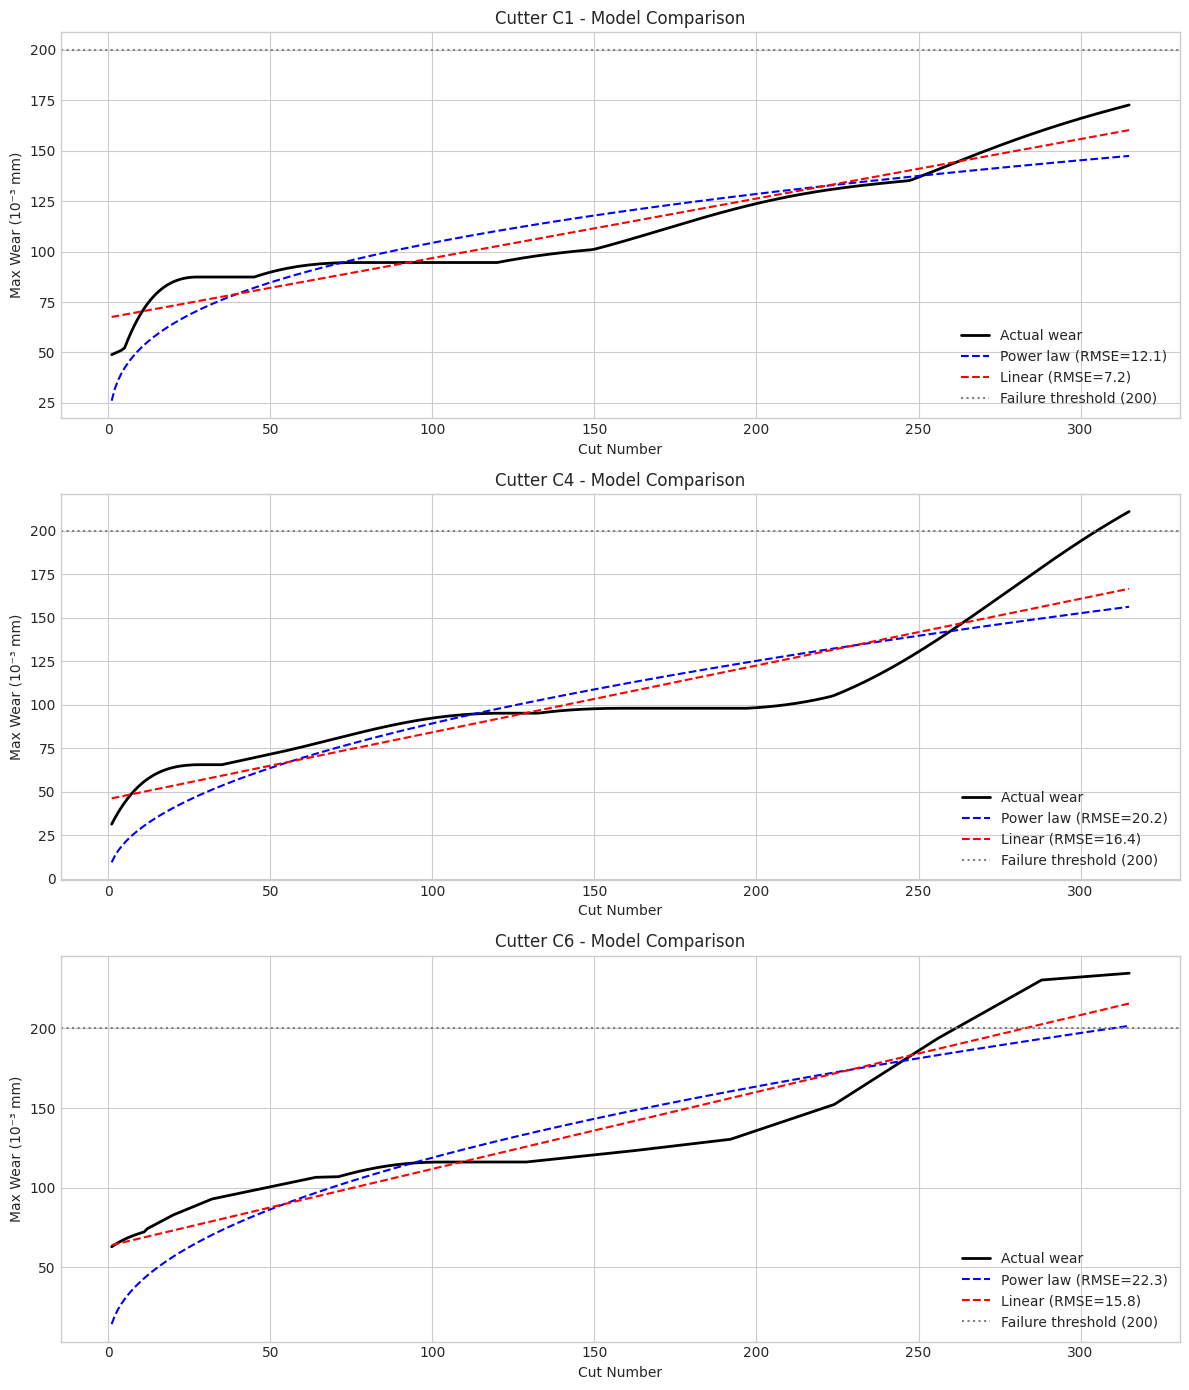

Plot saved


In [6]:
# Plot model fits for all three cutters
fig, axes = plt.subplots(3, 1, figsize=(12, 14))

cutters = [
    ('c1', wear_c1, results_c1),
    ('c4', wear_c4, results_c4),
    ('c6', wear_c6, results_c6)
]

for ax, (cutter_id, wear_df, results) in zip(axes, cutters):
    t = wear_df['cut'].values
    w = wear_df['max_wear'].values
    
    # Plot actual wear
    ax.plot(t, w, color='black', label='Actual wear', linewidth=2)
    
    # Plot power law fit
    params_pl = results['power_law']['params']
    w_pred_pl = power_law(t, *params_pl)
    ax.plot(t, w_pred_pl, color='blue', linestyle='--', 
            label=f'Power law (RMSE={results["power_law"]["rmse"]:.1f})')
    
    # Plot linear fit
    params_ln = results['linear']['params']
    w_pred_ln = linear_model(t, *params_ln)
    ax.plot(t, w_pred_ln, color='red', linestyle='--',
            label=f'Linear (RMSE={results["linear"]["rmse"]:.1f})')
    
    ax.axhline(y=200, color='gray', linestyle=':', label='Failure threshold (200)')
    ax.set_title(f'Cutter {cutter_id.upper()} - Model Comparison')
    ax.set_xlabel('Cut Number')
    ax.set_ylabel('Max Wear (10⁻³ mm)')
    ax.legend()

plt.tight_layout()
plt.savefig('/home/jupyter/plots/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

In [7]:
# Use power law to answer the challenge question
# For each wear threshold W, find the cut number where wear first crosses W

def invert_power_law(W, a, b):
    """
    Given wear threshold W, find cut number t where a*t^b = W
    Solving: t = (W/a)^(1/b)
    """
    return (W / a) ** (1 / b)

# Wear thresholds from the challenge
wear_thresholds = np.arange(66, 166)  # 66 to 165 inclusive

# Get power law parameters for each cutter
params_c1 = results_c1['power_law']['params']
params_c4 = results_c4['power_law']['params']
params_c6 = results_c6['power_law']['params']

# For each threshold, get cut estimates from all three cutters
physics_predictions = []

for W in wear_thresholds:
    t_c1 = invert_power_law(W, *params_c1)
    t_c4 = invert_power_law(W, *params_c4)
    t_c6 = invert_power_law(W, *params_c6)
    
    physics_predictions.append({
        'wear_threshold': W,
        't_c1': t_c1,
        't_c4': t_c4,
        't_c6': t_c6,
        'median': np.median([t_c1, t_c4, t_c6]),
        'conservative': np.min([t_c1, t_c4, t_c6])  # worst case
    })

physics_df = pd.DataFrame(physics_predictions)
print(physics_df.head(10))

   wear_threshold       t_c1       t_c4       t_c6     median  conservative
0              66  21.844035  53.818366  27.936363  27.936363     21.844035
1              67  22.962427  55.503718  28.862745  28.862745     22.962427
2              68  24.120230  57.215704  29.805438  29.805438     24.120230
3              69  25.318222  58.954343  30.764482  30.764482     25.318222
4              70  26.557186  60.719656  31.739918  31.739918     26.557186
5              71  27.837908  62.511661  32.731786  32.731786     27.837908
6              72  29.161176  64.330378  33.740125  33.740125     29.161176
7              73  30.527784  66.175826  34.764975  34.764975     30.527784
8              74  31.938529  68.048023  35.806374  35.806374     31.938529
9              75  33.394210  69.946987  36.864360  36.864360     33.394210


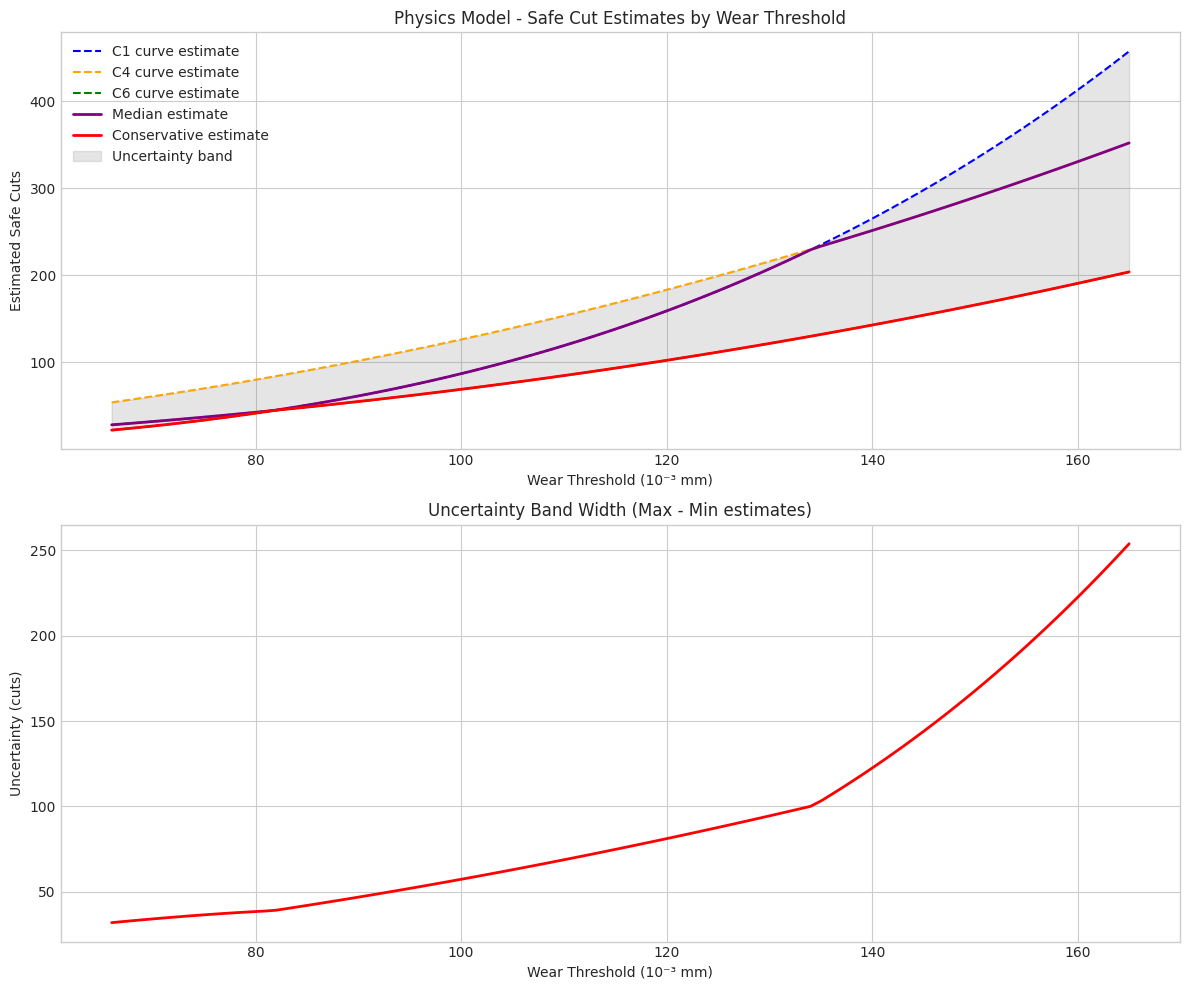

Plot saved


In [8]:
# Plot physics model predictions
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Top plot: all three curves + conservative estimate
axes[0].plot(physics_df['wear_threshold'], physics_df['t_c1'], 
             label='C1 curve estimate', color='blue', linestyle='--')
axes[0].plot(physics_df['wear_threshold'], physics_df['t_c4'], 
             label='C4 curve estimate', color='orange', linestyle='--')
axes[0].plot(physics_df['wear_threshold'], physics_df['t_c6'], 
             label='C6 curve estimate', color='green', linestyle='--')
axes[0].plot(physics_df['wear_threshold'], physics_df['median'], 
             label='Median estimate', color='purple', linewidth=2)
axes[0].plot(physics_df['wear_threshold'], physics_df['conservative'], 
             label='Conservative estimate', color='red', linewidth=2)
axes[0].fill_between(physics_df['wear_threshold'], 
                      physics_df['conservative'], 
                      physics_df[['t_c1','t_c4','t_c6']].max(axis=1),
                      alpha=0.2, color='gray', label='Uncertainty band')
axes[0].set_title('Physics Model - Safe Cut Estimates by Wear Threshold')
axes[0].set_xlabel('Wear Threshold (10⁻³ mm)')
axes[0].set_ylabel('Estimated Safe Cuts')
axes[0].legend()

# Bottom plot: uncertainty band width
band_width = physics_df[['t_c1','t_c4','t_c6']].max(axis=1) - physics_df['conservative']
axes[1].plot(physics_df['wear_threshold'], band_width, color='red', linewidth=2)
axes[1].set_title('Uncertainty Band Width (Max - Min estimates)')
axes[1].set_xlabel('Wear Threshold (10⁻³ mm)')
axes[1].set_ylabel('Uncertainty (cuts)')

plt.tight_layout()
plt.savefig('/home/jupyter/plots/physics_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

In [9]:
# Save physics predictions
physics_df.to_csv('/home/jupyter/physics_predictions.csv', index=False)
physics_df.to_csv('gcs://phm2010-data-temilola/processed/physics_predictions.csv', index=False)

# Upload new plots to bucket
!gsutil -m cp -r /home/jupyter/plots/* gs://phm2010-data-temilola/plots/

print("Physics predictions saved")
print("\nSummary of physics model:")
print(f"Wear threshold range: {physics_df['wear_threshold'].min()} to {physics_df['wear_threshold'].max()}")
print(f"Conservative estimate range: {physics_df['conservative'].min():.0f} to {physics_df['conservative'].max():.0f} cuts")
print(f"Median estimate range: {physics_df['median'].min():.0f} to {physics_df['median'].max():.0f} cuts")

/opt/conda/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.storage_control_v2 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.storage_control_v2 past that date.
  warnings.warn(message, FutureWarning)


Copying file:///home/jupyter/plots/all_cutters_wear_progression.png [Content-Type=image/png]...
Copying file:///home/jupyter/plots/c1_wear_progression.png [Content-Type=image/png]...
Copying file:///home/jupyter/plots/correlation_heatmap.png [Content-Type=image/png]...
Copying file:///home/jupyter/plots/features_vs_wear.png [Content-Type=image/png]...
Copying file:///home/jupyter/plots/physics_predictions.png [Content-Type=image/png]...
Copying file:///home/jupyter/plots/model_comparison.png [Content-Type=image/png]...
Copying file:///home/jupyter/plots/sample_sensor_signals.png [Content-Type=image/png]...
/ [7/7 files][  2.2 MiB/  2.2 MiB] 100% Done                                    
Operation completed over 7 objects/2.2 MiB.                                      
Physics predictions saved

Summary of physics model:
Wear threshold range: 66 to 165
Conservative estimate range: 22 to 204 cuts
Median estimate range: 28 to 352 cuts
